# Find the Least Crowded Time for Gym---Using SGD

## Introduction
In this project, we will build a model to predict the best time to go ot the gym and avoid crowds.

The dataset contains the following columns:
- number_people: this is the number of people at the gym at each observation. This will be our target variable or label.
- date: a string value with the specific date and time information.
- timestamp: an integer (int), with the number of seconds since the start of the day (00:00).
- dayofweek: an integer (int). 0 is equal to Monday and 6 is equal to Sunday.
- is_weekend: a Boolean value defining if this observation happened during a weekend. 1 for yes, 0 for no.
- is_holiday: a Boolean value defining if the observation happened during a holiday. 1 for yes, 0 for no.
- temperature: a float, defining the temperature during the day of the observation in Fahrenheit.
- isstartof_semester: a Boolean defining if the observation happened in the first 2 weeks of a semester. 1 for yes, 0 for no.
- is_during_semester: a Boolean defining if the observation happened during the active semester. 1 for yes, 0 for no.
- month: an integer (int) defining the month of the year. 1 is equal to January, 12 is equal to December.
- hour: an integer (int) for the hour of the day from 0 to 23.

Let's explore the dataset first



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

In [2]:
%matplotlib inline

In [3]:
df=pd.read_csv('C:/Users/Public/Documents/yang/Data Science Project/data/crowdness_gym_data.csv')

In [4]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


There is no missing data. Let's run some EDA first.

## EDA

The dependent variable is 'number_people' column. The columns of 'date' and 'timestamp' won't be useful since the dataset already has other variables extracted from the date and time objects, such as 'day_of_week','hour','month', is_weekend',and 'is_holiday'.

In [6]:
#drop 'date' and 'timestamp' columns
df_c=df.copy().drop(['date','timestamp'],axis=1)

array([[<Axes: title={'center': 'number_people'}>]], dtype=object)

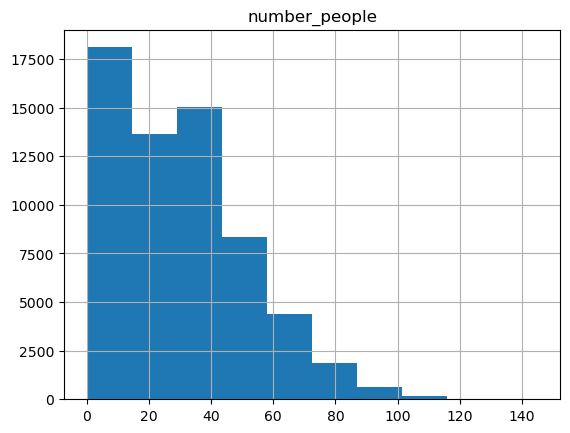

In [7]:
#check the distribution of 'number_people'
df_c.hist('number_people')

array([[<Axes: title={'center': 'temperature'}>]], dtype=object)

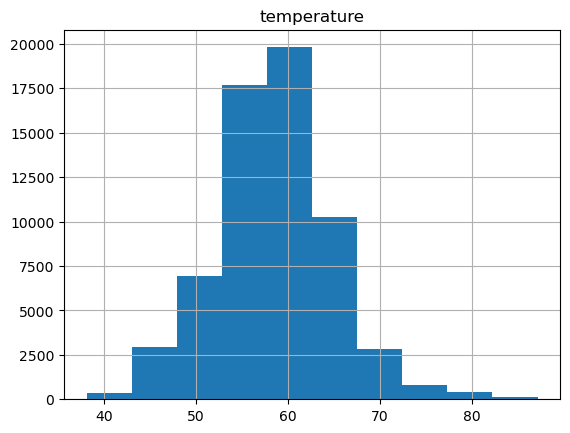

In [8]:
#check the distribution of 'temperature'
df_c.hist('temperature')

The temperature of most days fell between 50 and 70

In [9]:
df_c.columns

Index(['number_people', 'day_of_week', 'is_weekend', 'is_holiday',
       'temperature', 'is_start_of_semester', 'is_during_semester', 'month',
       'hour'],
      dtype='object')

The columns of 'day_of_week', 'is_weekend', 'is_holiday','is_start_of_semester', 'is_during_semester', 'month','hour' are the numerical data. However, we can treat them as categorical data and plot the countplot to see if there are any trends with'number_people'.

In [10]:
#make all assumed categorical data in a list
cat_cols=['day_of_week', 'is_weekend', 'is_holiday','is_start_of_semester', 'is_during_semester', 'month','hour']

In [11]:
#checking the unique values
for col in cat_cols:
    print(df_c[col].unique())

[4 5 6 0 1 2 3]
[0 1]
[0 1]
[0 1]
[0 1]
[ 8  9 10 11 12  1  2  3  4  5  6  7]
[17 18 19 20 21 22 23  0  1  5  6  7  8  9 10 11 12 13 14 15 16  2  3  4]


The dataset contains 24/7 and 12 months observations. Let's plot data to see if we can drop some unuseful data points.

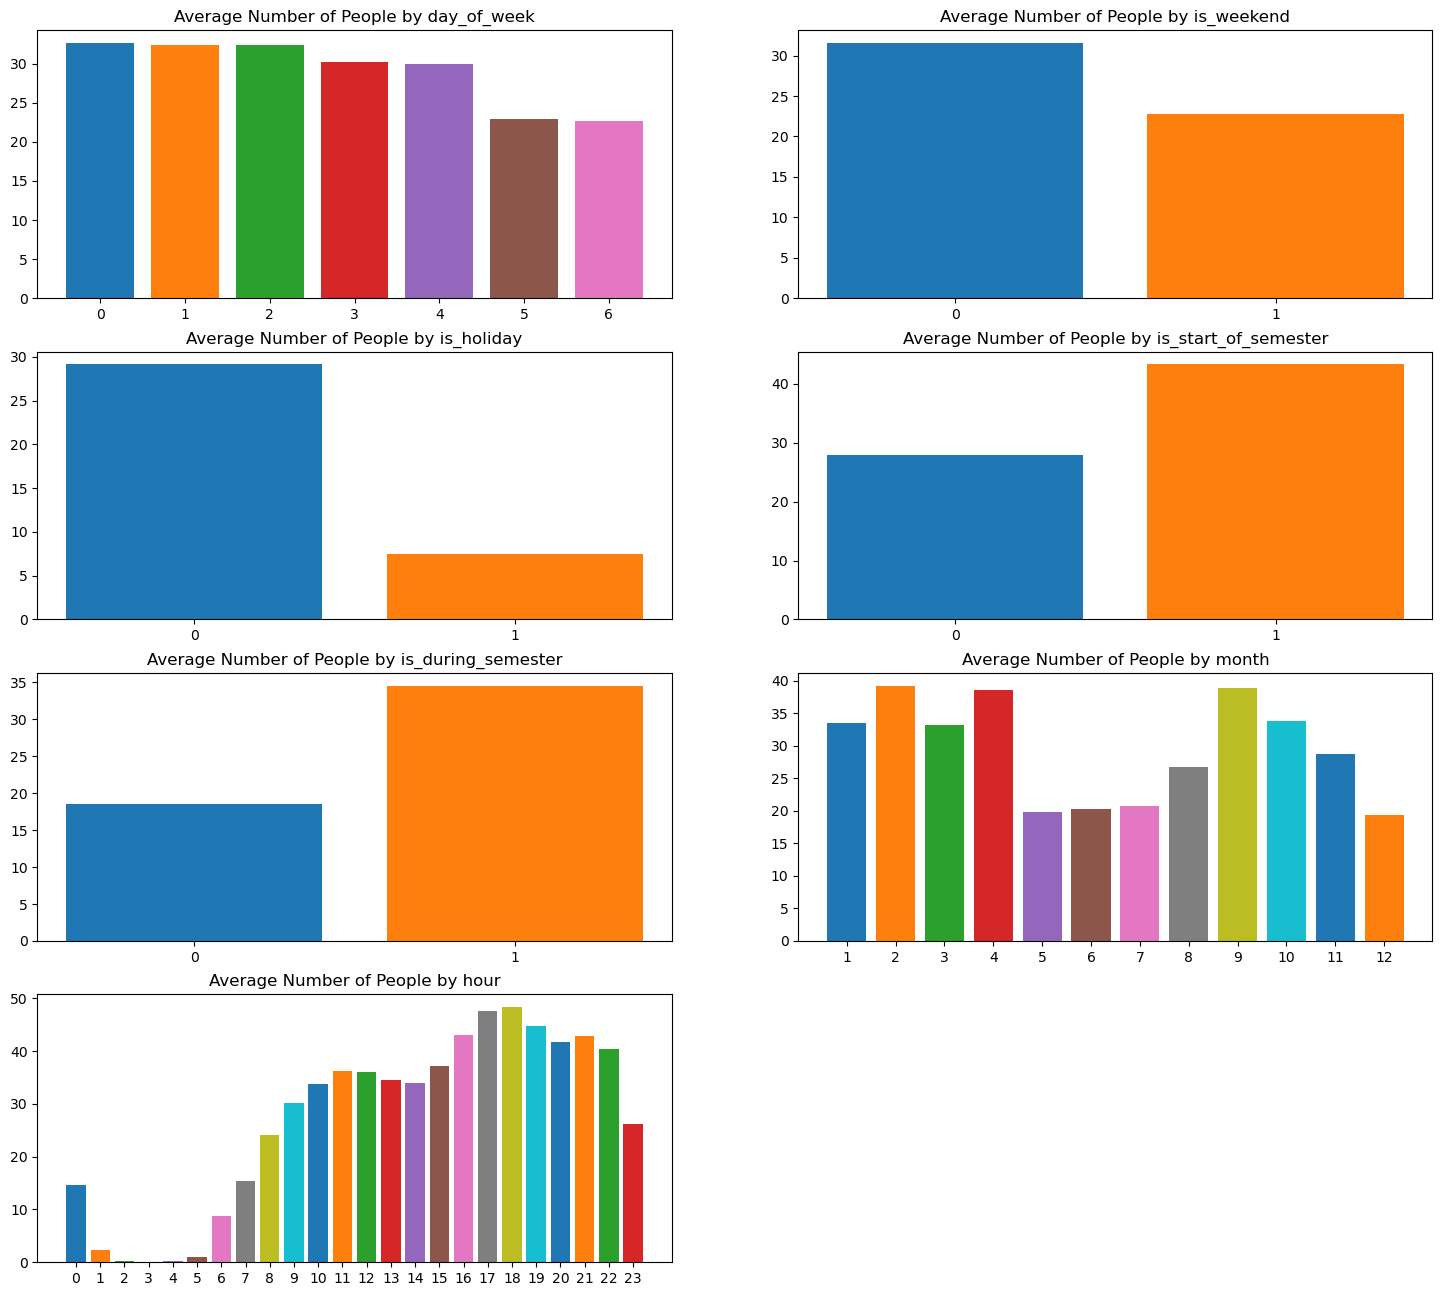

In [12]:
plt.figure(figsize=(18,16))
for idx, col in enumerate(cat_cols):
    ax=plt.subplot(4,2,idx+1)
    avg=df_c.groupby(col)['number_people'].mean()
    ax.bar(avg.index,avg,color=sns.color_palette('tab10'))
    ax.set_title(f'Average Number of People by {col}')
    xticks=sorted(avg.index)
    ax.set_xticks(xticks)
plt.show()

- The average number of people is relatively lower on Friday and Saturday than other days of week
- The weekends and holidays experience fewer people.
- The first two weeks of semester have more people than the rest of semester
- There are more people during semester than during break
- May, June, July, and December have the lowest number of gym visits, which might attribute to summer or winter break
- From 1 am to 5 am, there are very few people visiting gym.

Let's investigate the correlations between dependent variable and all independent variables.

<Axes: >

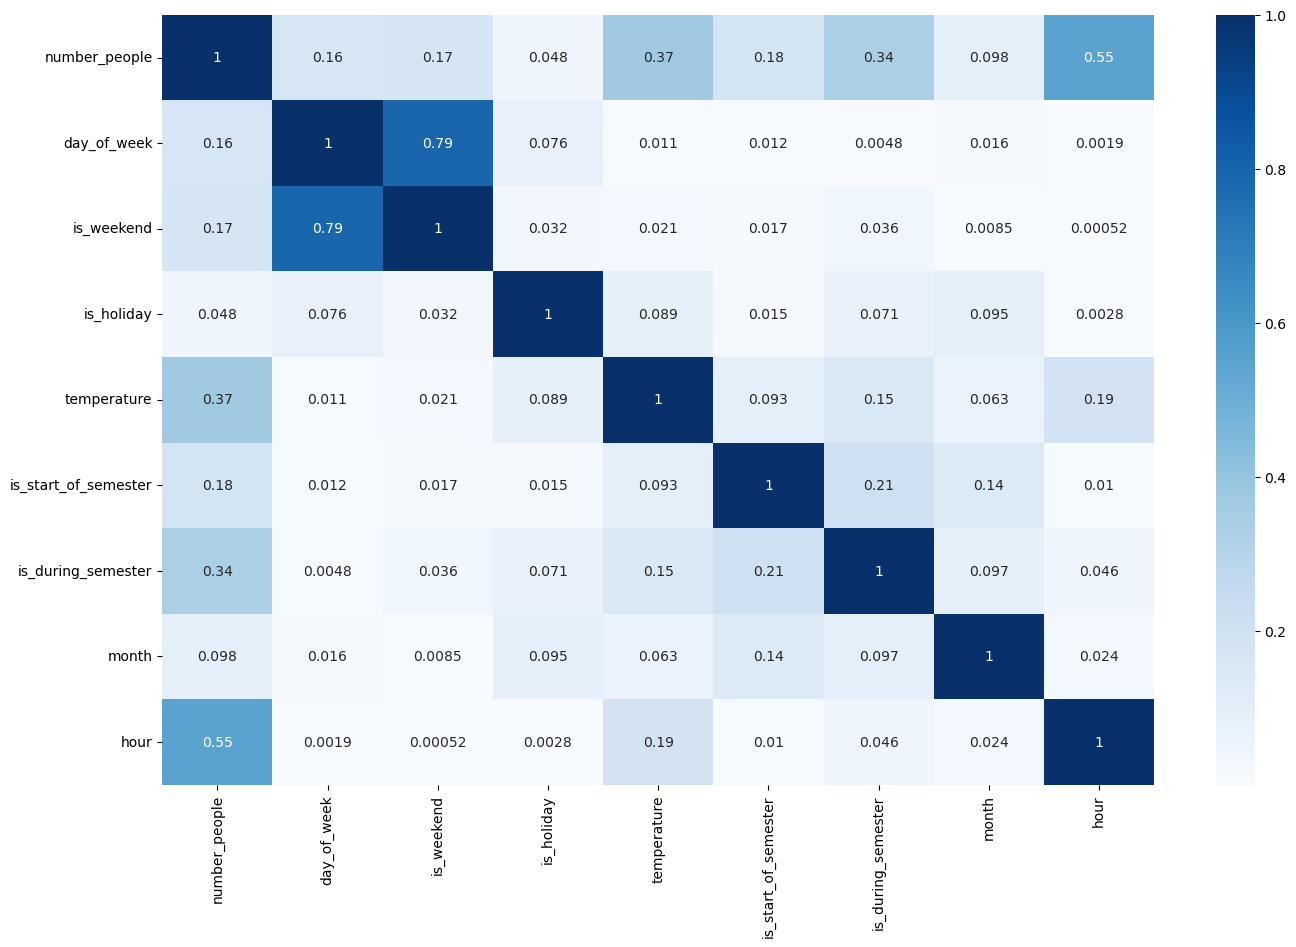

In [13]:
# check the correlations
corr=df_c.corr()
plt.figure(figsize=(16,10))
sns.heatmap(abs(corr),annot=True, cmap='Blues')

## Build the Model
Let's use all independent variables in the model first and make adjustment later accordingly.

In [14]:
X=df_c.drop('number_people',axis=1)
y=df_c['number_people']

#Split the data: training(75%) and test(25%)
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25, random_state=68)

In [15]:
#Standardize the X
scaler=StandardScaler()
scaler.fit(X_train)
X_train_std=scaler.transform(X_train)
X_test_std=scaler.transform(X_test)

In [16]:
#initialize the model, set random_state =62 for reproducibility
gd_v1=SGDRegressor(loss='squared_error',random_state=62)

In [17]:
gd_v1.fit(X_train_std,y_train)

SGDRegressor(random_state=62)

## Evaluate the Model Performance

let's evaluate the performance on training dataset first

In [18]:
#calculate the prediction on training dataset
y_pred_train_v1=gd_v1.predict(X_train_std)

In [19]:
#mean squared error on training dataset
mse_train_v1=mean_squared_error(y_train, y_pred_train_v1)

In [20]:
mse_train_v1

250.45153891717558

In [21]:
#mean absolute error on training dataset
mae_train_v1=mean_absolute_error(y_train,y_pred_train_v1)

In [22]:
mae_train_v1

12.119679801765855

In [23]:
#R-Squared on training dataset
r2_train_v1=r2_score(y_train,y_pred_train_v1)

In [24]:
r2_train_v1

0.5116805441603616

let's evaluate the performance on test dataset

In [25]:
#calculate the prediction on test dataset
y_pred_test_v1=gd_v1.predict(X_test_std)

In [26]:
mse_test_v1=mean_squared_error(y_test,y_pred_test_v1)


In [27]:
mse_test_v1

260.8698115349898

In [28]:
mae_test_v1=mean_absolute_error(y_test,y_pred_test_v1)

In [29]:
mae_test_v1

12.374827120479694

In [30]:
r2_test_v1=r2_score(y_test,y_pred_test_v1)

In [31]:
r2_test_v1

0.4987808675414289

- The mean absoluate error is around 12.12 on training dataset with a R-Squared of 0.5117
- The mean absoluate error is around 12.37 on test dataset with a R-Squared of 0.4988.
- The model performance is consistent with training and test datasets.
- The prediction errors are relatively high. The model only explains about 50% of variance

## Cross Validation

In [33]:
# perform 10 folds cross validation
X_scaled=scaler.transform(X)
mse_cv=cross_val_score(gd_v1,X_scaled,y,scoring='neg_mean_squared_error',cv=10)

In [34]:
mse_cv

array([-633.58036345, -595.94407208, -485.81970195, -254.88997456,
       -132.52248051,  -91.64561005, -231.92782504, -262.81448561,
       -253.49371401, -216.25911414])

In [35]:
mse_cv_mean=abs(mse_cv).mean()

In [36]:
mse_cv_mean

315.8897341415247

In [37]:
np.sqrt(mse_cv_mean)

17.77328709444386

In [38]:
df_c['number_people'].mean()

29.072542776276855

## Summary

- The 10 folds cross validation revealed that the average error of prediction is 17.77. Compared to the average number of people visiting gym(29.07), the error is relatively high. 
- However, based on the EDA, if you want to go to the gym without experiencing the crowdness, we suggest  that 6 am, 7 am, and 8 am on Friday and Saturday during May, June, July, and December would be a good time.
